# Experiment No. 06
## Logistic Regression for Heart Disease Classification

**Aim:** To build and evaluate a leakage-safe logistic regression model for binary heart-disease classification, compare it with a naive baseline, interpret its coefficients, and study how the probability threshold changes sensitivity and specificity.

### Objectives

- Inspect the supplied dataset and perform explicit data-quality checks.
- Preserve the distinction between continuous measurements and category codes.
- Impute, encode, and scale features inside a scikit-learn pipeline.
- Evaluate accuracy, precision, recall (sensitivity), specificity, F1-score, ROC-AUC, and average precision.
- Compare logistic regression with a majority-class dummy classifier.
- Interpret coefficients as changes in log-odds and odds ratios.
- Examine threshold trade-offs without presenting the model as a clinical system.

> **Educational-use notice:** This small historical dataset is used only to demonstrate machine-learning methods. The resulting model is not validated for diagnosis or patient-care decisions.

## 1. Data dictionary

| Column | Meaning | Treatment in this notebook |
| --- | --- | --- |
| `age` | Age in years | Continuous |
| `sex` | Recorded sex (`female`, `male`) | Categorical |
| `cp` | Chest-pain type code (0-3) | Categorical |
| `trestbps` | Resting blood pressure (mm Hg) | Continuous |
| `chol` | Serum cholesterol (mg/dL) | Continuous |
| `fbs` | Fasting blood sugar indicator | Categorical/binary |
| `restecg` | Resting ECG result code | Categorical |
| `thalach` | Maximum heart rate achieved (bpm) | Continuous |
| `exang` | Exercise-induced angina indicator | Categorical/binary |
| `oldpeak` | ST depression induced by exercise | Continuous |
| `slope` | Peak exercise ST-segment slope code | Categorical |
| `ca` | Number-of-vessels code (0-4) | Categorical |
| `thal` | Thalassemia/test-result code | Categorical |
| `target` | Heart-disease label (`yes`, `no`) | Binary target |

## 2. Import libraries

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score,
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

## 3. Load and audit the dataset

The path logic works when the notebook is launched either from the repository root or from the `Week 6` directory. The source CSV is never overwritten.

In [2]:
file_name = "heart disease classification dataset.csv"
candidate_paths = [Path(file_name), Path("Week 6") / file_name]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(f"Could not find {file_name!r} in the notebook directory or Week 6/.")

raw_data = pd.read_csv(data_path)
index_columns = [column for column in raw_data.columns if column.startswith("Unnamed:")]
data = raw_data.drop(columns=index_columns).copy()
duplicate_rows = int(data.duplicated().sum())
if duplicate_rows:
    data = data.drop_duplicates().reset_index(drop=True)

target_map = {"no": 0, "yes": 1}
data["target"] = data["target"].str.strip().str.lower().map(target_map)

print(f"Loaded: {data_path.resolve()}")
print(f"Raw shape: {raw_data.shape}")
print(f"Removed saved-index columns: {index_columns or 'none'}")
print(f"Removed exact duplicate rows from the analysis copy: {duplicate_rows}")
print(f"Analysis shape: {data.shape}")
data.head()

Loaded: D:\Programming\SEM-5 ML labs\Week 6\heart disease classification dataset.csv
Raw shape: (303, 15)
Removed saved-index columns: ['Unnamed: 0']
Removed exact duplicate rows from the analysis copy: 1
Analysis shape: (302, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,male,3,145.0000,233.0000,1,0,150.0000,0,2.3000,0,0,1,1
1,37,male,2,130.0000,250.0000,0,1,187.0000,0,3.5000,0,0,2,1
2,41,female,1,130.0000,204.0000,0,0,172.0000,0,1.4000,2,0,2,1
3,56,male,1,120.0000,236.0000,0,1,178.0000,0,0.8000,2,0,2,1
4,57,female,0,NaN,354.0000,0,1,163.0000,1,0.6000,2,0,2,1


In [3]:
quality_summary = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "unique": data.nunique(dropna=False),
})
display(quality_summary)

target_summary = (
    data["target"].value_counts().sort_index()
    .rename(index={0: "No disease", 1: "Disease"})
    .rename_axis("class").to_frame("rows")
)
target_summary["percent"] = 100 * target_summary["rows"] / len(data)
display(target_summary)
data.describe().T

,dtype,missing,unique
age,int64,0,41
sex,str,0,2
cp,int64,0,4
trestbps,float64,4,50
chol,float64,1,153
fbs,int64,0,2
restecg,int64,0,3
thalach,float64,5,90
exang,int64,0,2
oldpeak,float64,0,40


,rows,percent
class,,
No disease,138,45.6954
Disease,164,54.3046


,count,mean,std,min,25%,50%,75%,max
age,302.0000,54.4205,9.0480,29.0000,48.0000,55.5000,61.0000,77.0000
cp,302.0000,0.9636,1.0320,0.0000,0.0000,1.0000,2.0000,3.0000
trestbps,298.0000,131.6913,17.6549,94.0000,120.0000,130.0000,140.0000,200.0000
chol,301.0000,246.5548,51.8309,126.0000,211.0000,241.0000,275.0000,564.0000
fbs,302.0000,0.1490,0.3567,0.0000,0.0000,0.0000,0.0000,1.0000
restecg,302.0000,0.5265,0.5260,0.0000,0.0000,1.0000,1.0000,2.0000
thalach,297.0000,149.7879,22.5616,71.0000,134.0000,152.0000,166.0000,202.0000
exang,302.0000,0.3278,0.4702,0.0000,0.0000,0.0000,1.0000,1.0000
oldpeak,302.0000,1.0430,1.1615,0.0000,0.0000,0.8000,1.6000,6.2000
slope,302.0000,1.3974,0.6163,0.0000,1.0000,1.0000,2.0000,2.0000


The missing measurements are not filled globally. Imputers will learn replacement values from each training fold only, which prevents information from the held-out data leaking into model fitting.

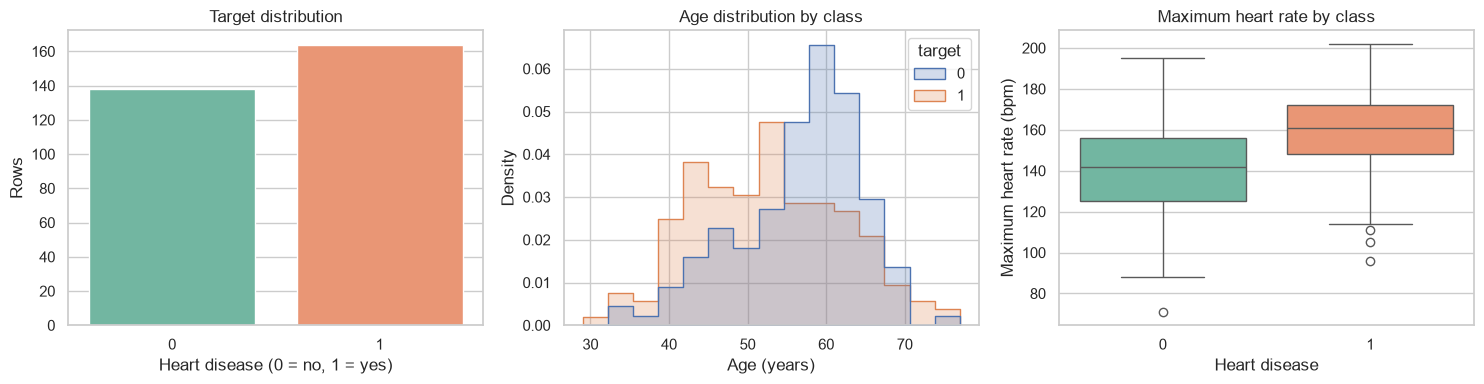

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=data, x="target", hue="target", palette="Set2", legend=False, ax=axes[0])
axes[0].set(title="Target distribution", xlabel="Heart disease (0 = no, 1 = yes)", ylabel="Rows")

sns.histplot(data=data, x="age", hue="target", bins=15, element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set(title="Age distribution by class", xlabel="Age (years)")

sns.boxplot(data=data, x="target", y="thalach", hue="target", palette="Set2", legend=False, ax=axes[2])
axes[2].set(title="Maximum heart rate by class", xlabel="Heart disease", ylabel="Maximum heart rate (bpm)")

plt.tight_layout()
plt.show()

## 4. Define features and create a stratified split

The integer-coded clinical categories are one-hot encoded; they are not treated as measurements with equal spacing. Continuous variables are median-imputed and standardized.

In [5]:
continuous_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
feature_columns = continuous_features + categorical_features

X = data[feature_columns].copy()
y = data["target"].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "positive_rows": [int(y_train.sum()), int(y_test.sum())],
    "positive_rate": [y_train.mean(), y_test.mean()],
}, index=["Training", "Testing"])
split_summary

,rows,positive_rows,positive_rate
Training,241,131,0.5436
Testing,61,33,0.5410


## 5. Build leakage-safe preprocessing and models

In [6]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first")),
])
preprocessor = ColumnTransformer([
    ("continuous", numeric_pipeline, continuous_features),
    ("categorical", categorical_pipeline, categorical_features),
])

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
dummy_model = DummyClassifier(strategy="most_frequent")

dummy_model.fit(X_train, y_train)
logistic_model.fit(X_train, y_train)
print("Both models fitted successfully.")

Both models fitted successfully.


## 6. Evaluate held-out performance

Class `1` (disease = yes) is the positive class. Sensitivity is recall for class 1; specificity is recall for class 0.

In [7]:
def evaluate_classifier(name, model, features, labels):
    predictions = model.predict(features)
    probabilities = model.predict_proba(features)[:, 1]
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        "Model": name,
        "Accuracy": accuracy_score(labels, predictions),
        "Precision": precision_score(labels, predictions, zero_division=0),
        "Sensitivity (Recall)": recall_score(labels, predictions, zero_division=0),
        "Specificity": tn / (tn + fp),
        "F1-score": f1_score(labels, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(labels, probabilities),
        "Average Precision": average_precision_score(labels, probabilities),
    }

models = {"Majority-class baseline": dummy_model, "Logistic regression": logistic_model}
test_results = pd.DataFrame([
    evaluate_classifier(name, model, X_test, y_test)
    for name, model in models.items()
]).set_index("Model")
test_results

,Accuracy,Precision,Sensitivity (Recall),Specificity,F1-score,ROC-AUC,Average Precision
Model,,,,,,,
Majority-class baseline,0.5410,0.5410,1.0000,0.0000,0.7021,0.5000,0.5410
Logistic regression,0.8361,0.8286,0.8788,0.7857,0.8529,0.8853,0.9023


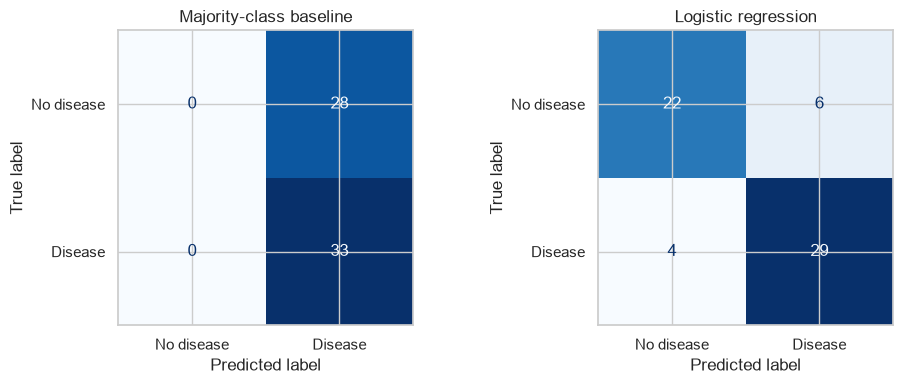

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, model.predict(X_test), labels=[0, 1],
        display_labels=["No disease", "Disease"], cmap="Blues", colorbar=False, ax=ax
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [9]:
logistic_predictions = logistic_model.predict(X_test)
print(classification_report(
    y_test, logistic_predictions, labels=[0, 1],
    target_names=["No disease", "Disease"], digits=4, zero_division=0
))

              precision    recall  f1-score   support

  No disease     0.8462    0.7857    0.8148        28
     Disease     0.8286    0.8788    0.8529        33

    accuracy                         0.8361        61
   macro avg     0.8374    0.8323    0.8339        61
weighted avg     0.8366    0.8361    0.8354        61



## 7. ROC and precision-recall curves

ROC-AUC measures ranking across all thresholds. The precision-recall curve emphasizes performance on the positive class and should be read relative to the positive-class prevalence.

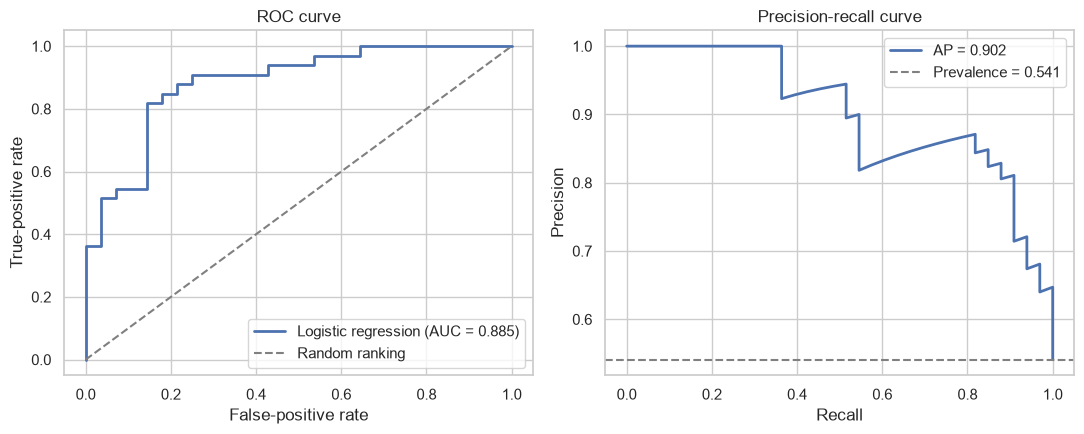

In [10]:
test_probabilities = logistic_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, test_probabilities)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_probabilities)
roc_auc = roc_auc_score(y_test, test_probabilities)
average_precision = average_precision_score(y_test, test_probabilities)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, linewidth=2, label=f"Logistic regression (AUC = {roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Random ranking")
axes[0].set(title="ROC curve", xlabel="False-positive rate", ylabel="True-positive rate")
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, linewidth=2, label=f"AP = {average_precision:.3f}")
axes[1].axhline(y=y_test.mean(), linestyle="--", color="gray", label=f"Prevalence = {y_test.mean():.3f}")
axes[1].set(title="Precision-recall curve", xlabel="Recall", ylabel="Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Five-fold cross-validation on the training set

Cross-validation estimates how much performance changes across different training/validation partitions. The untouched test set is not included in these folds.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy", "precision": "precision", "recall": "recall",
    "f1": "f1", "roc_auc": "roc_auc", "average_precision": "average_precision",
}
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Found unknown categories.*", category=UserWarning)
    cv_scores = cross_validate(logistic_model, X_train, y_train, cv=cv, scoring=scoring)
cv_summary = pd.DataFrame({
    metric.replace("test_", "").replace("_", " " ).title(): [values.mean(), values.std(ddof=1)]
    for metric, values in cv_scores.items() if metric.startswith("test_")
}, index=["Mean", "Standard deviation"]).T
cv_summary

,Mean,Standard deviation
Accuracy,0.8509,0.0568
Precision,0.8606,0.0623
Recall,0.8701,0.0586
F1,0.8641,0.0496
Roc Auc,0.9088,0.0425
Average Precision,0.9196,0.0295


## 9. Interpret logistic-regression coefficients

For a continuous feature, an odds ratio corresponds to a one-standard-deviation increase because those variables were standardized. For an encoded category, it compares that category with the encoder's dropped reference level while other modeled features stay fixed. Associations are not causal effects.

,Feature,Coefficient,Odds ratio,Absolute coefficient
0,categorical__cp_2,1.4737,4.3653,1.4737
1,categorical__cp_3,1.3751,3.9555,1.3751
2,categorical__ca_2,-1.3196,0.2673,1.3196
3,categorical__ca_1,-1.2280,0.2929,1.2280
4,categorical__sex_male,-0.9670,0.3802,0.9670
5,categorical__thal_2,0.9105,2.4856,0.9105
6,categorical__thal_3,-0.8069,0.4462,0.8069
7,categorical__exang_1,-0.7620,0.4667,0.7620
8,categorical__cp_1,0.7374,2.0905,0.7374
9,categorical__ca_3,-0.6383,0.5282,0.6383


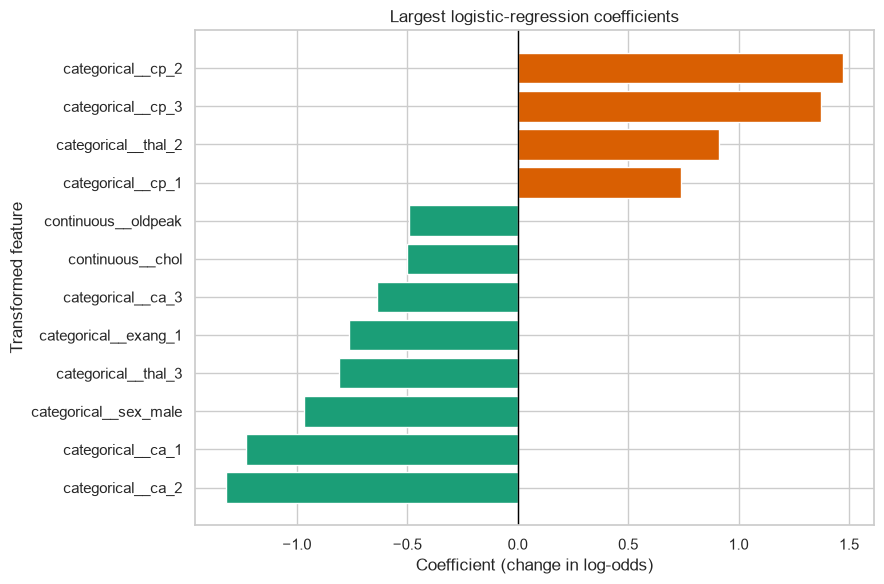

In [12]:
feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = logistic_model.named_steps["classifier"].coef_[0]
coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds ratio": np.exp(coefficients),
})
coefficient_table["Absolute coefficient"] = coefficient_table["Coefficient"].abs()
coefficient_table = coefficient_table.sort_values("Absolute coefficient", ascending=False).reset_index(drop=True)
display(coefficient_table.head(12))

top_coefficients = coefficient_table.head(12).sort_values("Coefficient")
colors = np.where(top_coefficients["Coefficient"] >= 0, "#d95f02", "#1b9e77")
plt.figure(figsize=(9, 6))
plt.barh(top_coefficients["Feature"], top_coefficients["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Largest logistic-regression coefficients")
plt.xlabel("Coefficient (change in log-odds)")
plt.ylabel("Transformed feature")
plt.tight_layout()
plt.show()

## 10. Probability-threshold trade-off

The default threshold is 0.50. Lower thresholds usually identify more positive cases (higher sensitivity) but also create more false positives (lower specificity). These held-out comparisons are illustrative; a real threshold must be selected using separate validation data, clinical costs, and external validation.

,Accuracy,Precision,Sensitivity,Specificity,F1-score,Predicted positive rate
Threshold,,,,,,
0.3000,0.7541,0.7143,0.9091,0.5714,0.8000,0.6885
0.4000,0.8197,0.7895,0.9091,0.7143,0.8451,0.6230
0.5000,0.8361,0.8286,0.8788,0.7857,0.8529,0.5738
0.6000,0.8361,0.8710,0.8182,0.8571,0.8438,0.5082
0.7000,0.7377,0.8400,0.6364,0.8571,0.7241,0.4098


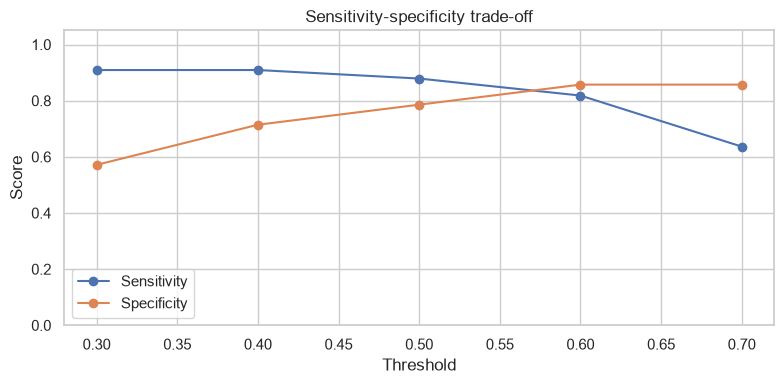

In [13]:
threshold_rows = []
for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    threshold_predictions = (test_probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, threshold_predictions, labels=[0, 1]).ravel()
    threshold_rows.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, threshold_predictions),
        "Precision": precision_score(y_test, threshold_predictions, zero_division=0),
        "Sensitivity": recall_score(y_test, threshold_predictions, zero_division=0),
        "Specificity": tn / (tn + fp),
        "F1-score": f1_score(y_test, threshold_predictions, zero_division=0),
        "Predicted positive rate": threshold_predictions.mean(),
    })
threshold_results = pd.DataFrame(threshold_rows).set_index("Threshold")
display(threshold_results)

threshold_results[["Sensitivity", "Specificity"]].plot(marker="o", figsize=(8, 4))
plt.ylim(0, 1.05)
plt.title("Sensitivity-specificity trade-off")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## 11. Automated checks

In [14]:
assert data.shape[1] == 14, "Unexpected number of analysis columns"
assert set(feature_columns) == set(data.columns) - {"target"}
assert y.isna().sum() == 0 and set(y.unique()) == {0, 1}
assert X_train.index.intersection(X_test.index).empty, "Train/test row overlap detected"
assert len(X_train) + len(X_test) == len(data)
assert abs(y_train.mean() - y_test.mean()) < 0.03, "Stratification check failed"
assert np.isfinite(test_probabilities).all()
assert ((test_probabilities >= 0) & (test_probabilities <= 1)).all()
assert test_results.loc["Logistic regression", "ROC-AUC"] > 0.5
assert test_results.loc["Logistic regression", "Accuracy"] > test_results.loc["Majority-class baseline", "Accuracy"]
assert coefficient_table.shape[0] == len(feature_names)
print("All data, split, probability, performance, and coefficient checks passed.")

All data, split, probability, performance, and coefficient checks passed.


## 12. Conclusion

Logistic regression provides a transparent probabilistic baseline for this binary classification problem. The pipeline keeps imputation, encoding, and scaling within model fitting, which protects the test set and the cross-validation folds from preprocessing leakage. Performance must be judged with multiple metrics: accuracy alone hides the balance between false positives and false negatives, while ROC-AUC and average precision summarize ranking quality across thresholds.

The coefficient table helps explain the fitted associations, but coefficients do not establish causation. Threshold results also show that sensitivity and specificity cannot generally be maximized together. Because the dataset is small and lacks external validation, the exercise demonstrates methodology rather than a deployable medical model.

## Viva Questions - Short Answers

1. **Why is logistic regression used for classification?** It models the probability of a class using a sigmoid transformation and predicts a class by comparing that probability with a threshold.
2. **What does the sigmoid function do?** It maps any real-valued linear score to a value between 0 and 1.
3. **What is log-odds?** It is $\log(p/(1-p))$, where $p$ is the probability of the positive class. Logistic regression models log-odds as a linear function of the features.
4. **Why use a pipeline?** It ensures imputation, encoding, and scaling are learned from training data only and are applied consistently to new data.
5. **Why are coded columns one-hot encoded?** Their numeric codes represent categories, not equal-interval measurements; one-hot encoding avoids imposing a false linear order.
6. **What is sensitivity?** Sensitivity (recall) is the proportion of actual positive cases correctly identified: $TP/(TP+FN)$.
7. **What is specificity?** Specificity is the proportion of actual negative cases correctly identified: $TN/(TN+FP)$.
8. **What does ROC-AUC measure?** It measures how well predicted scores rank a randomly chosen positive case above a randomly chosen negative case across thresholds.
9. **What does an odds ratio above 1 mean?** Holding modeled features fixed, the associated feature value is linked with higher fitted odds of the positive class relative to its reference or previous standardized value.
10. **Why compare against a dummy classifier?** It shows whether the learned model adds predictive value beyond always choosing the majority class.
11. **Why use stratified splitting?** It keeps approximately the same class proportion in the training and testing sets.
12. **Can this model be used for diagnosis?** No. It is an educational model trained on a small dataset and has not undergone clinical or external validation.